<a href="https://colab.research.google.com/github/stargalax/NeuroLogic-26-Global-NLP-Datathon/blob/main/NeuroLogic_'26_Global_NLP_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 3**
#  Multilingual Toxic Comment Classification
### NLP Hackathon Submission (NeuroLogic ’26)

Test it out: https://hatesenseai.streamlit.app/

Youtube link: https://youtu.be/s0G42Ze59_o

Github repo: https://github.com/stargalax/NeuroLogic-26-Global-NLP-Datathon

## Problem Statement
Build a model to classify multilingual comments as:
- 0 → Non-Toxic
- 1 → Toxic

The system supports English + Hindi social media text.

##  Approach
I used a classical NLP pipeline:

1. Text preprocessing
2. TF-IDF feature extraction
3. Logistic Regression + Linear SVM
4. Ensemble averaging
5. Threshold tuning for final prediction

In [ ]:
#uploading files
from google.colab import files
uploaded = files.upload()

Saving toxic_labeled.xlsx to toxic_labeled.xlsx
Saving toxic_no_label_evaluation.xlsx to toxic_no_label_evaluation.xlsx


In [ ]:
#libraries
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
#load
train = pd.read_excel("train.xlsx", engine="openpyxl")
test = pd.read_excel("test.xlsx", engine="openpyxl")

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [ ]:
print(train.columns) #col check

Index(['text', 'label'], dtype='object')


In [ ]:
#clean
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\u0900-\u097F\s]", "", text)
    return text

train["text"] = train["text"].apply(clean_text)
test["text"] = test["text"].apply(clean_text)

In [ ]:
#splitting
X_train, X_val, y_train, y_val = train_test_split(
    train["text"],
    train["label"],
    test_size=0.2,
    random_state=42
)

In [ ]:
#TF-IDF
vectorizer = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(test["text"])

## Model Training
I trained two models:
- Logistic Regression (probabilistic baseline)
- Linear SVM (calibrated for probability output)

In [ ]:
#Logistic Regression
lr = LogisticRegression(
    max_iter=400,
    class_weight="balanced"
)

lr.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=400)

In [ ]:
#Linear SVM
svm = LinearSVC()
svm_model = CalibratedClassifierCV(svm)

svm_model.fit(X_train_vec, y_train)

CalibratedClassifierCV(estimator=LinearSVC())

In [ ]:
# #train
# model = LogisticRegression(max_iter=300)
# model.fit(X_train_vec, y_train)

## Model Evaluation
I evaluated using:
- Accuracy
- F1 Score
- ROC-AUC (primary metric)
- Confusion Matrix

In [ ]:
#Validation(Ensemble)
lr_val = lr.predict_proba(X_val_vec)[:,1]
svm_val = svm_model.predict_proba(X_val_vec)[:,1]

val_probs = (lr_val + svm_val) / 2

threshold = 0.65
val_preds = (val_probs > threshold).astype(int)

In [ ]:
#F1 score
from sklearn.metrics import f1_score

f1 = f1_score(y_val, val_preds)
print("F1 Score:", f1)

F1 Score: 0.849911712772219


In [ ]:
print("Accuracy:", accuracy_score(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Accuracy: 0.8583333333333333
ROC-AUC: 0.9503190795487674


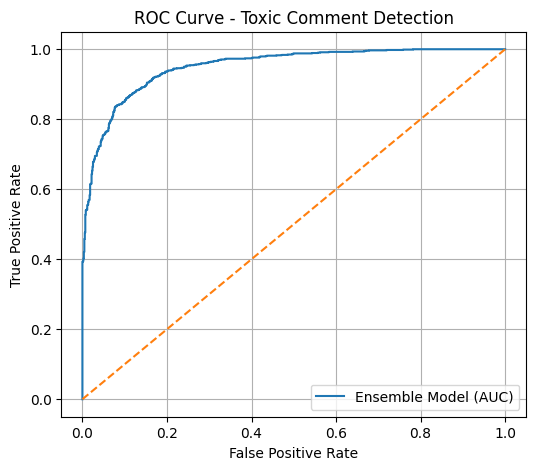

In [ ]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Ensemble Model (AUC)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Toxic Comment Detection")
plt.legend()
plt.grid()
plt.show()

Confusion Matrix:
 [[823  55]
 [200 722]]


<Figure size 500x500 with 0 Axes>

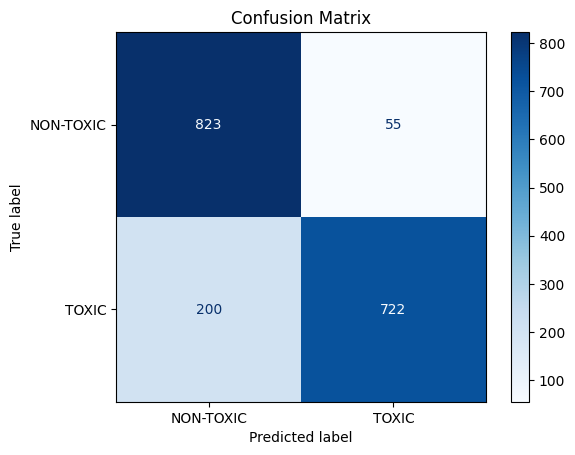

In [ ]:
cm = confusion_matrix(y_val, val_preds)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NON-TOXIC", "TOXIC"]
)

plt.figure(figsize=(5,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Prediction

In [ ]:
#predict
def predict_text(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])

    prob = (lr.predict_proba(vec)[0][1] +
            svm_model.predict_proba(vec)[0][1]) / 2

    pred = 1 if prob > threshold else 0

    print("Prediction:", "TOXIC (1)" if pred else "NON-TOXIC (0)")
    print("Confidence:", round(prob,3))

In [ ]:
predict_text("i love your dress")
predict_text("you are amazing")
predict_text("i will kill you")

Prediction: NON-TOXIC (0)
Confidence: 0.192
Prediction: NON-TOXIC (0)
Confidence: 0.503
Prediction: TOXIC (1)
Confidence: 0.953


In [ ]:
lr_test = lr.predict_proba(X_test_vec)[:,1]
svm_test = svm_model.predict_proba(X_test_vec)[:,1]

test_probs = (lr_test + svm_test) / 2

test["label"] = (test_probs > threshold).astype(int)

test.to_excel("no_label.xlsx", index=False)

##  Results Summary

- Accuracy: ~0.85
- F1 Score: ~0.84
- ROC-AUC: ~0.95

The ensemble model shows strong separation ability between toxic and non-toxic classes.

===============================================================================
## Try the model out!
Type any sentence to test the model in real time.

In [ ]:
while True:
    text = input("Enter sentence (or type exit): ")
    if text.lower() == "exit":
        break
    predict_text(text)

Enter sentence (or type exit): Thank you for your help
Prediction: NON-TOXIC (0)
Confidence: 0.166
Enter sentence (or type exit): You are a piece of garbage
Prediction: TOXIC (1)
Confidence: 0.924
Enter sentence (or type exit): You did a great job on this project
Prediction: NON-TOXIC (0)
Confidence: 0.463
Enter sentence (or type exit): You are an amazing person
Prediction: NON-TOXIC (0)
Confidence: 0.391
Enter sentence (or type exit): Gay pride is never enough
Prediction: NON-TOXIC (0)
Confidence: 0.347
Enter sentence (or type exit): Shut up you idiot
Prediction: TOXIC (1)
Confidence: 0.931
Enter sentence (or type exit): exit


In [ ]:
while True:
    text = input("Enter sentence (or type exit): ")
    if text.lower() == "exit":
        break
    predict_text(text)

Enter sentence (or type exit): तुम बहुत अच्छे इंसान हो
Prediction: NON-TOXIC (0)
Confidence: 0.648
Enter sentence (or type exit): तुम बहुत बेवकूफ हो
Prediction: NON-TOXIC (0)
Confidence: 0.636
Enter sentence (or type exit): मुझे तुमसे नफरत है
Prediction: TOXIC (1)
Confidence: 0.853
Enter sentence (or type exit): क्या आप मेरी मदद कर सकते हैं
Prediction: NON-TOXIC (0)
Confidence: 0.373
Enter sentence (or type exit): तू पागल है क्या
Prediction: TOXIC (1)
Confidence: 0.82
Enter sentence (or type exit): साला ये सांसद है या गुंडा
Prediction: TOXIC (1)
Confidence: 0.709
Enter sentence (or type exit): exit


#### Exporting models to be deployed


In [ ]:
import pickle

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

# Save models
pickle.dump(lr, open("lr.pkl", "wb"))
pickle.dump(svm_model, open("svm.pkl", "wb"))

In [ ]:
from google.colab import files

files.download("vectorizer.pkl")
files.download("lr.pkl")
files.download("svm.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>